# Capstone Step 1: Data Loading, Market Exploration & Visualization

**Module 2 : Stock Market Deep Learning System**

Objective: download/load S&P 500 stock data, explore market microstructure, compute
technical baseline statistics, and create publication-quality visualizations.

Data source: `demos/01_download_data.py` (50 S&P 500 tickers across sectors, 2005–2025,
plus VIX and 10-Year Treasury yield).

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110

DATA_DIR = "../data"
pd.set_option("display.max_columns", None)

Matplotlib is building the font cache; this may take a moment.


## 1. Load Data

Load the three files produced by `demos/01_download_data.py`: stock OHLCV, VIX, and the
10-Year Treasury yield. Print shape and date range as required by Step 1.

In [2]:
stocks = pd.read_csv(os.path.join(DATA_DIR, "sp500_stocks.csv"), parse_dates=["Date"])
vix = pd.read_csv(os.path.join(DATA_DIR, "vix.csv"), parse_dates=["Date"])
treasury = pd.read_csv(os.path.join(DATA_DIR, "treasury_10y.csv"), parse_dates=["Date"])

print("Stocks shape:", stocks.shape)
print("Date range:", stocks["Date"].min().date(), "to", stocks["Date"].max().date())
print("Tickers:", stocks["Ticker"].nunique())
print()
print("VIX shape:", vix.shape)
print("Treasury shape:", treasury.shape)

stocks.head()

Stocks shape: (259073, 7)
Date range: 2005-01-03 to 2025-12-30
Tickers: 50

VIX shape: (5282, 6)
Treasury shape: (5277, 6)


,Date,Close,High,Low,Open,Volume,Ticker
0,2005-01-03,0.946491,0.973709,0.936172,0.968773,691992000,AAPL
1,2005-01-04,0.956211,0.979091,0.941704,0.953967,1096810400,AAPL
2,2005-01-05,0.964586,0.975802,0.957856,0.963987,680433600,AAPL
3,2005-01-06,0.965334,0.970717,0.947089,0.967128,705555200,AAPL
4,2005-01-07,1.035621,1.041304,0.968324,0.972063,2227450400,AAPL


## 2. Daily Log Returns

We use `log_return = log(close_t / close_t-1)` rather than the simple percentage return
for three reasons that matter directly for this project:

1. **Additivity across time.** Log returns sum across periods
   (`weekly log return = sum of 5 daily log returns`), which makes aggregating a strategy's
   cumulative performance mathematically clean. Simple returns compound multiplicatively
   and do not sum this way — a +10% day followed by a -10% day does not net to 0%.
2. **Symmetry.** Simple returns are bounded below at -100% but unbounded above, which
   skews their distribution. Log returns are unbounded in both directions and are
   approximately normally distributed at short (daily) horizons — a better-behaved input
   for neural networks and for statistical analysis.
3. **Direct compatibility with our modeling target.** The capstone's regression target
   (next-day return) and the loss functions we will use later (MSE, Huber) both assume an
   approximately symmetric, roughly normal target — log returns satisfy this far better
   than simple returns.

We use **Adjusted Close**, not raw Close, so that stock splits and dividends do not
appear as spurious price jumps.

In [3]:
def compute_log_returns(df, price_col="Adj Close"):
    """Compute daily log returns per ticker, preserving temporal order."""
    price_col = price_col if price_col in df.columns else "Close"
    df = df.sort_values(["Ticker", "Date"]).copy()
    df["LogReturn"] = df.groupby("Ticker")[price_col].transform(
        lambda s: np.log(s / s.shift(1))
    )
    return df

stocks = compute_log_returns(stocks)
stocks[["Date", "Ticker", "Adj Close" if "Adj Close" in stocks.columns else "Close", "LogReturn"]].head()

,Date,Ticker,Close,LogReturn
0,2005-01-03,AAPL,0.946491,NaN
1,2005-01-04,AAPL,0.956211,0.010217
2,2005-01-05,AAPL,0.964586,0.008720
3,2005-01-06,AAPL,0.965334,0.000775
4,2005-01-07,AAPL,1.035621,0.070282


## 3. Missing Data Report

Check for trading halts, delistings, and gaps. Weekends/holidays are expected gaps, not
missing data, we flag tickers whose observed trading-day count deviates meaningfully
from the median, which usually indicates a late IPO/listing rather than a data quality
issue (e.g. a ticker that only started trading partway through the 2005–2025 window).

In [4]:
days_per_ticker = stocks.groupby("Ticker")["Date"].count().sort_values()
median_days = days_per_ticker.median()

missing_report = pd.DataFrame({
    "TradingDays": days_per_ticker,
    "PctOfMedian": (days_per_ticker / median_days * 100).round(1),
}).sort_values("TradingDays")

print(f"Median trading days across tickers: {median_days:.0f}")
print("\nTickers with materially fewer trading days than the median (likely late listing):")
missing_report[missing_report["PctOfMedian"] < 95]

Median trading days across tickers: 5282

Tickers with materially fewer trading days than the median (likely late listing):


,TradingDays,PctOfMedian
Ticker,,
ABBV,3269,61.9
META,3424,64.8
AVGO,4126,78.1


In [6]:
# NaN check: after computing log returns, the first day per ticker is NaN by construction
n_nan_returns = stocks["LogReturn"].isna().sum()
print(f"NaN log returns (expected: 1 per ticker = {stocks['Ticker'].nunique()}): {n_nan_returns}")

NaN log returns (expected: 1 per ticker = 50): 50


In [7]:
# Check for any unexpected NaNs in price columns
price_col = "Adj Close" if "Adj Close" in stocks.columns else "Close"
print(f"NaN {price_col} values: {stocks[price_col].isna().sum()}")
print(f"NaN Volume values: {stocks['Volume'].isna().sum()}")

NaN Close values: 0
NaN Volume values: 0


**Handling decision:** the single leading NaN per ticker (the first trading day, 
where no prior price exists to compute a return from) will be dropped before any 
modeling step, this affects only 50 rows out of ~259K and is unavoidable by 
construction.  

Beyond that, no unexpected missing values were found in price or 
volume data. The shorter histories for ABBV, META, and AVGO reflect real IPO/listing 
dates (2013, 2012, and 2009 respectively) rather than data quality issues, and no 
imputation is needed for these gaps, they will simply have fewer usable rows for 
training and evaluation.

## 4. Summary Statistics per Stock

Annualized return, annualized volatility, Sharpe ratio, and max drawdown per ticker.
Ranked by Sharpe ratio (risk-adjusted performance), not raw return.

In [8]:
def summary_stats(df, price_col="Adj Close"):
    price_col = price_col if price_col in df.columns else "Close"
    rows = []
    for ticker, g in df.groupby("Ticker"):
        r = g["LogReturn"].dropna().values
        if len(r) < 2:
            continue
        ann_return = r.mean() * 252
        ann_vol = r.std(ddof=1) * np.sqrt(252)
        sharpe = ann_return / ann_vol if ann_vol > 0 else 0.0
        cumulative = np.cumprod(1 + r)
        running_max = np.maximum.accumulate(cumulative)
        max_dd = ((cumulative - running_max) / running_max).min()
        rows.append({
            "Ticker": ticker,
            "AnnReturn": round(ann_return, 4), # combien cette action a rapporté en moyenne par an ?
            "AnnVol": round(ann_vol, 4), # à quel point le prix de cette action bouge-t-il, dans un sens comme dans l'autre ?
            "Sharpe": round(sharpe, 4), # pour chaque unité de risque prise, combien de rendement j'ai obtenu ?
            "MaxDrawdown": round(max_dd, 4), # dans le pire des cas, combien j'aurais pu perdre avant que ça remonte ?
            "TradingDays": len(g),
        })
    return pd.DataFrame(rows).sort_values("Sharpe", ascending=False).reset_index(drop=True)

In [9]:
stats = summary_stats(stocks)
print("Top 10 by Sharpe ratio:")
display(stats.head(10))

Top 10 by Sharpe ratio:


,Ticker,AnnReturn,AnnVol,Sharpe,MaxDrawdown,TradingDays
0,AVGO,0.3498,0.3779,0.9257,-0.5216,4126
1,AAPL,0.2702,0.3216,0.8402,-0.6743,5282
2,COST,0.1570,0.2238,0.7018,-0.5187,5282
3,ABBV,0.1849,0.2648,0.6982,-0.4964,3269
4,NVDA,0.3315,0.4868,0.6811,-0.8996,5282
5,MCD,0.1355,0.1998,0.6784,-0.3998,5282
6,GOOGL,0.1972,0.3000,0.6574,-0.6985,5282
7,LLY,0.1700,0.2606,0.6524,-0.5636,5282
8,QQQ,0.1389,0.2165,0.6416,-0.5737,5282
9,NFLX,0.3012,0.4997,0.6027,-0.8825,5282


In [10]:
print("\nBottom 10 by Sharpe ratio:")
display(stats.tail(10))


Bottom 10 by Sharpe ratio:


,Ticker,AnnReturn,AnnVol,Sharpe,MaxDrawdown,TradingDays
40,CMCSA,0.0660,0.2810,0.2348,-0.7047,5282
41,PLD,0.0885,0.4059,0.2181,-0.9332,5282
42,WFC,0.0808,0.3940,0.2051,-0.8703,5282
43,MS,0.0859,0.4521,0.1899,-0.9567,5282
44,PFE,0.0418,0.2337,0.1790,-0.6289,5282
45,UPS,0.0392,0.2478,0.1581,-0.6385,5282
46,GE,0.0518,0.3286,0.1578,-0.9073,5282
47,SLB,0.0295,0.3864,0.0763,-0.9419,5282
48,BAC,0.0308,0.4555,0.0675,-0.9776,5282
49,C,-0.0447,0.4816,-0.0929,-0.9941,5282


**Interpretation:** The top 10 is dominated by technology and consumer-staple names 
(AVGO, AAPL, COST, NVDA, GOOGL, NFLX) with Sharpe ratios between 0.60 and 0.93,
reflecting the sustained outperformance of large-cap tech over 2005–2025. Note that 
AVGO's #1 ranking is partly an artifact of its shorter trading history (4126 days, 
listed since 2009), which excludes most of the 2008 financial crisis and is therefore 
not directly comparable to tickers with the full 5282-day window. 
MCD stands out as the lowest-return name in the top 10 (13.6% annualized) but earns its place through 
the lowest volatility and smallest max drawdown of the group, a clear illustration 
that Sharpe rewards consistency, not just raw return.

The bottom 10 is dominated by financials (WFC, MS, BAC, C) and other cyclical/legacy 
names (GE, SLB), all carrying max drawdowns between -63% and -99%. This pattern is 
consistent with the 2008 financial crisis, which hit bank stocks especially hard.  
Citigroup (C) is the only ticker in the dataset with a negative annualized return 
over the full period, combined with the highest volatility (0.48), the worst 
possible risk/return combination. This split (tech/consumer at the top, financials 
at the bottom) is a reminder that sector performance is highly dependent on the 
chosen time window, which motivates using walk-forward validation rather than a 
single static split later in the LSTM modeling step.

## 5. Distribution & Pattern Visualizations (2×3 Grid)

Six panels: AAPL daily returns, SPY daily returns, AAPL rolling 30-day volatility,
correlation heatmap of 10 selected stocks, volume trends, and VIX vs. realized volatility.

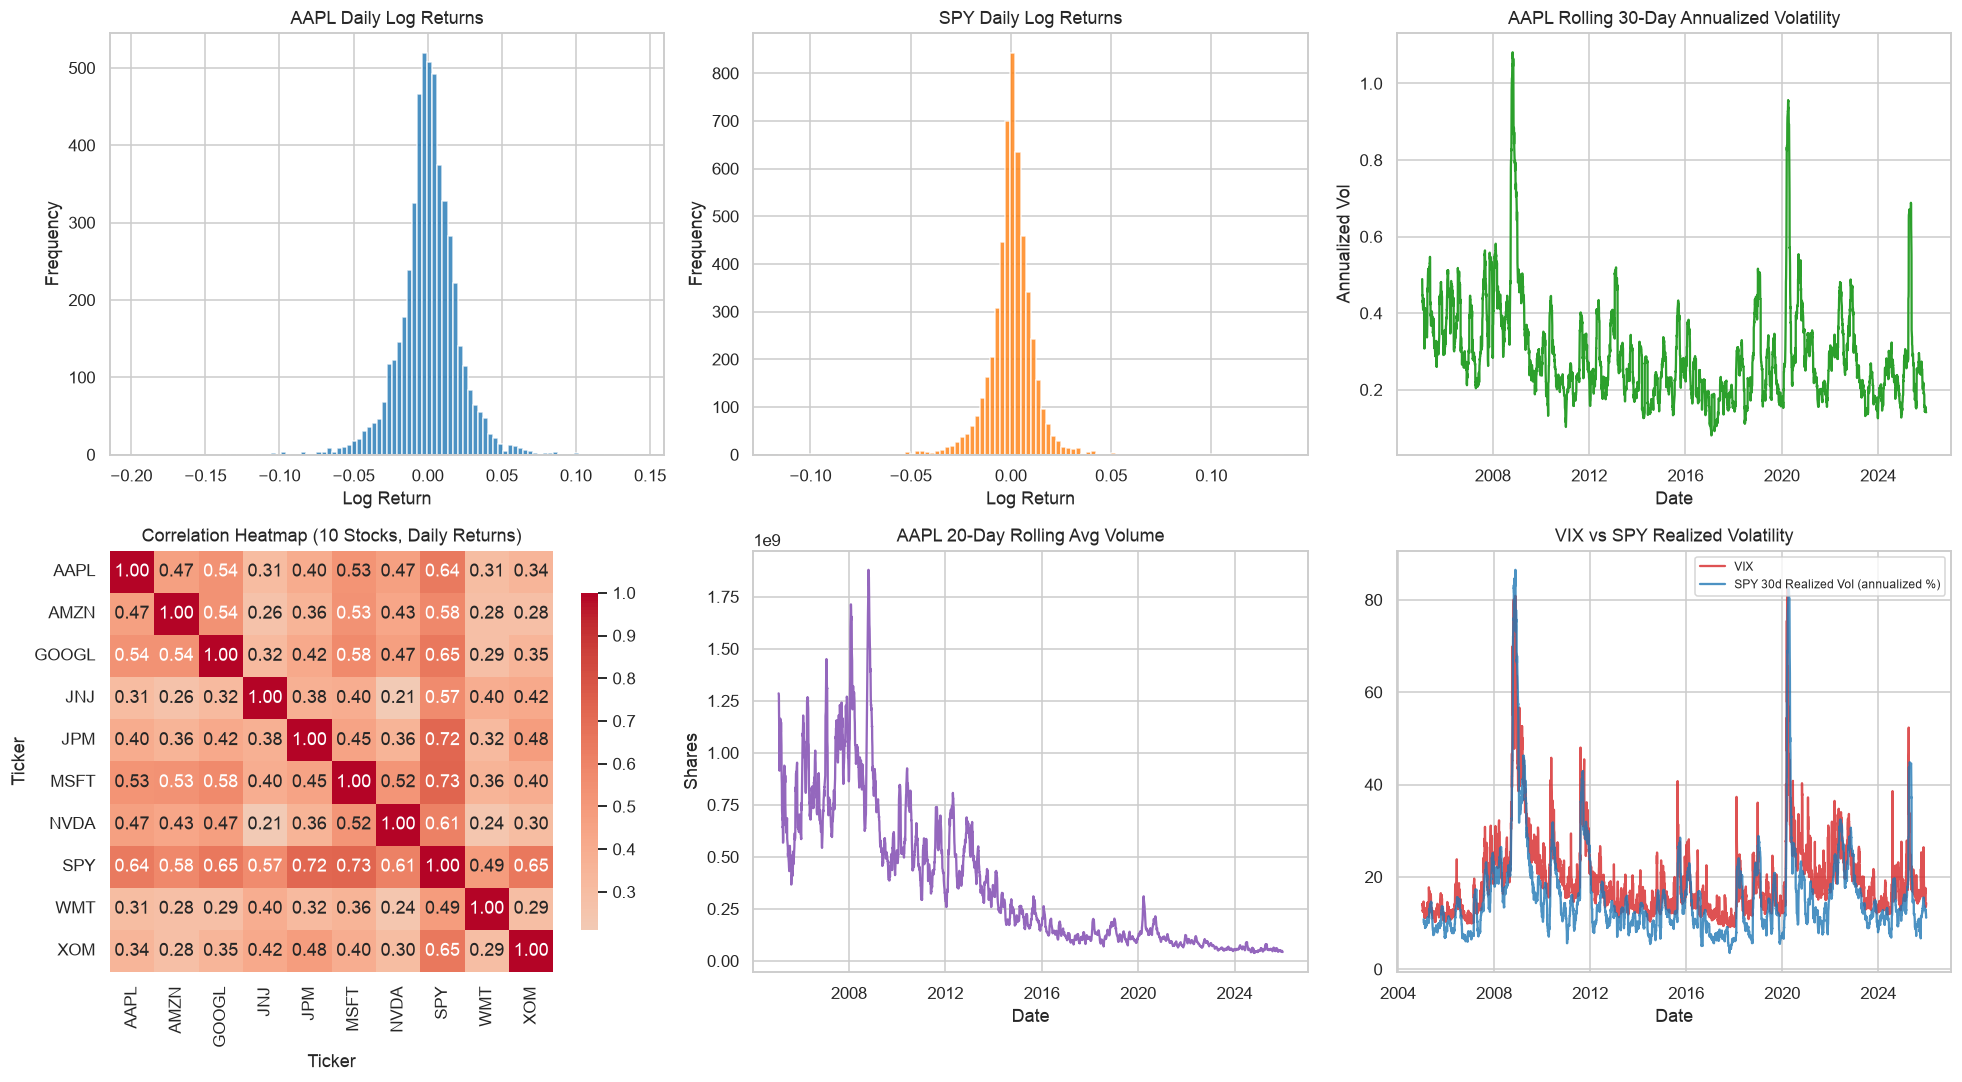

In [11]:
def get_ticker(df, ticker):
    return df[df["Ticker"] == ticker].sort_values("Date").reset_index(drop=True)

aapl = get_ticker(stocks, "AAPL")
spy = get_ticker(stocks, "SPY")

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# (1) AAPL daily return distribution
axes[0, 0].hist(aapl["LogReturn"].dropna(), bins=100, color="#1f77b4", alpha=0.8)
axes[0, 0].set_title("AAPL Daily Log Returns")
axes[0, 0].set_xlabel("Log Return")
axes[0, 0].set_ylabel("Frequency")

# (2) SPY daily return distribution
axes[0, 1].hist(spy["LogReturn"].dropna(), bins=100, color="#ff7f0e", alpha=0.8)
axes[0, 1].set_title("SPY Daily Log Returns")
axes[0, 1].set_xlabel("Log Return")
axes[0, 1].set_ylabel("Frequency")

# (3) AAPL rolling 30-day volatility
aapl_vol30 = aapl.set_index("Date")["LogReturn"].rolling(30, min_periods=15).std() * np.sqrt(252)
axes[0, 2].plot(aapl_vol30.index, aapl_vol30.values, color="#2ca02c")
axes[0, 2].set_title("AAPL Rolling 30-Day Annualized Volatility")
axes[0, 2].set_xlabel("Date")
axes[0, 2].set_ylabel("Annualized Vol")

# (4) Correlation heatmap of 10 selected stocks
sample_tickers = ["AAPL", "MSFT", "GOOGL", "AMZN", "JPM", "XOM", "JNJ", "WMT", "NVDA", "SPY"]
pivot = stocks[stocks["Ticker"].isin(sample_tickers)].pivot(
    index="Date", columns="Ticker", values="LogReturn"
)
corr = pivot.corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=axes[1, 0],
            cbar_kws={"shrink": 0.8})
axes[1, 0].set_title("Correlation Heatmap (10 Stocks, Daily Returns)")

# (5) Volume trends (AAPL, indexed to start = 100 for readability)
aapl_vol_idx = aapl.set_index("Date")["Volume"].rolling(20).mean()
axes[1, 1].plot(aapl_vol_idx.index, aapl_vol_idx.values, color="#9467bd")
axes[1, 1].set_title("AAPL 20-Day Rolling Avg Volume")
axes[1, 1].set_xlabel("Date")
axes[1, 1].set_ylabel("Shares")

# (6) VIX vs SPY realized volatility
vix_series = vix.set_index("Date")["Close"] if "Close" in vix.columns else vix.set_index("Date").iloc[:, 0]
spy_rv30 = spy.set_index("Date")["LogReturn"].rolling(30, min_periods=15).std() * np.sqrt(252) * 100
axes[1, 2].plot(vix_series.index, vix_series.values, label="VIX", color="#d62728", alpha=0.8)
axes[1, 2].plot(spy_rv30.index, spy_rv30.values, label="SPY 30d Realized Vol (annualized %)",
                 color="#1f77b4", alpha=0.8)
axes[1, 2].set_title("VIX vs SPY Realized Volatility")
axes[1, 2].set_xlabel("Date")
axes[1, 2].legend(fontsize=8)

plt.tight_layout()
plt.savefig("../reports/figs_01_eda_grid.png", dpi=150, bbox_inches="tight")
plt.show()

**Interpretations:**

1. **AAPL daily returns:** the bulk of daily moves cluster tightly around zero (roughly ±3-5% on most days), but the distribution has strikingly wide tails, the full 20-year range extends to about -20% and +15% on the most extreme days, far beyond what a normal distribution would predict. These rare extreme days almost certainly correspond to earnings surprises, major news events, or early-history data artifacts, not typical daily behavior.

2. **SPY daily returns:** the bulk of daily moves are even tighter than AAPL, mostly within ±4-5%, though the full range still extends to roughly ±10% on the rarest days (likely 2008 or 2020 crisis sessions). This narrower everyday range, and the fact that even its extremes are less severe than AAPL's, is clear visual confirmation that diversification across 500 stocks dampens the extreme single-name moves seen in AAPL.

3. **AAPL rolling volatility:** a clear spike above 1.0 (100% annualized volatility) around 2008-2009, a nearly-as-severe spike approaching 1.0 around 2020, and a smaller third spike near 0.7 around 2024-2025, versus a baseline of roughly 0.15-0.30 the rest of the time. This is the clearest confirmation that financial volatility is non-stationary and clusters around crisis periods.

4. **Correlation heatmap:** SPY has the highest correlation with every stock in the sample (0.72 with JPM, 0.73 with MSFT), consistent with it being a weighted combination of these names. Notably, JPM and XOM (financials and energy, very different sectors) are correlated at 0.48, reflecting shared exposure to the broader economic cycle rather than sector-specific factors. WMT has the lowest average correlation with the rest of the group (0.24-0.49 range), consistent with its defensive, non-cyclical profile.

5. **AAPL volume:** a clear long-run decline, from a peak near 1.9B shares/day around 2008-2009 to roughly 0.05B today, largely explained by AAPL's multiple stock splits reducing the number of shares needed to trade the same dollar value, plus a smaller isolated spike around the 2020 volatility episode.

6. **VIX vs realized volatility:** the two series move almost in lockstep, with synchronized peaks around 80-85 during both the 2008 and 2020 crises. VIX sits above realized volatility during most of the period, consistent with VIX pricing in a "fear premium" where investors pay more for downside protection than what typically materializes. Interestingly, realized volatility briefly catches up to or exceeds VIX during the sharpest moments of the 2020 crash, since realized vol is backward-looking (last 30 days) while VIX is forward-looking, so realized vol can spike faster than VIX during an extremely abrupt shock.

## 6. Rolling 60-Day Correlation: AAPL vs SPY

Does correlation increase during market crashes? A common empirical finding is that individual-stock-to-market correlation rises during crises (the "correlation goes to 1 in a crash" effect), as systematic/macro risk dominates and idiosyncratic stock-specific factors are temporarily overwhelmed.

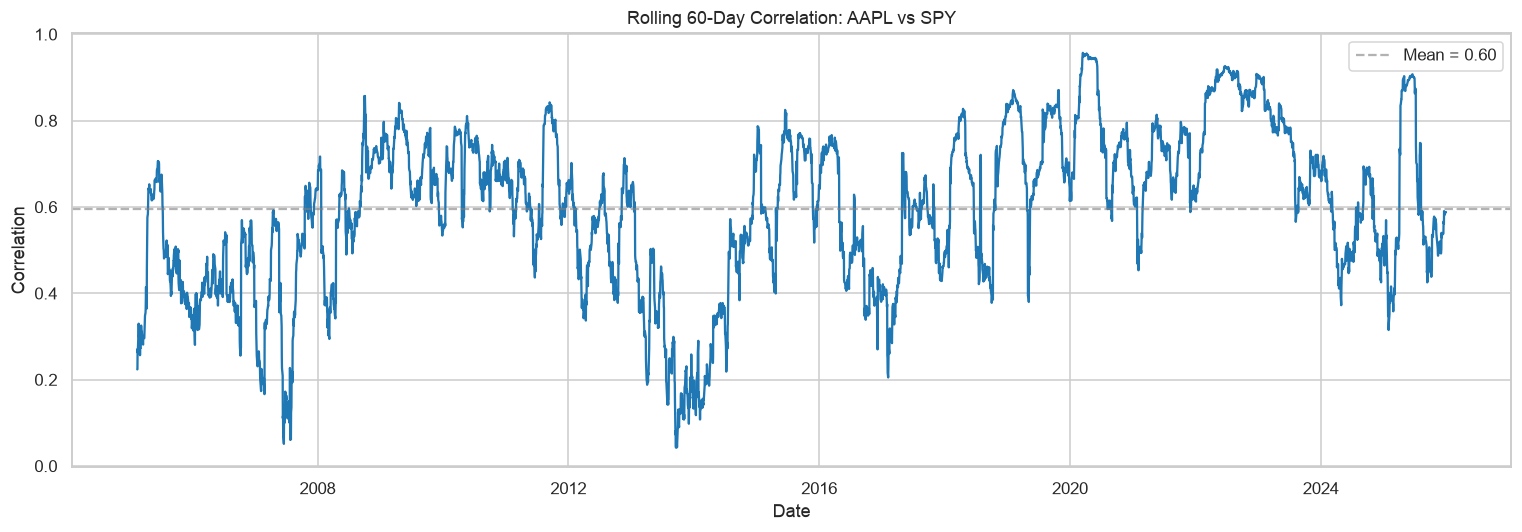

Mean rolling correlation: 0.596
Min: 0.042  |  Max: 0.957


In [12]:
merged = pd.merge(
    aapl[["Date", "LogReturn"]].rename(columns={"LogReturn": "AAPL"}),
    spy[["Date", "LogReturn"]].rename(columns={"LogReturn": "SPY"}),
    on="Date", how="inner"
).set_index("Date")

rolling_corr = merged["AAPL"].rolling(60, min_periods=30).corr(merged["SPY"])

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(rolling_corr.index, rolling_corr.values, color="#1f77b4")
ax.axhline(rolling_corr.mean(), color="gray", linestyle="--", alpha=0.6,
           label=f"Mean = {rolling_corr.mean():.2f}")
ax.set_title("Rolling 60-Day Correlation: AAPL vs SPY")
ax.set_xlabel("Date")
ax.set_ylabel("Correlation")
ax.legend()
plt.tight_layout()
plt.savefig("../reports/figs_01_rolling_corr_aapl_spy.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Mean rolling correlation: {rolling_corr.mean():.3f}")
print(f"Min: {rolling_corr.min():.3f}  |  Max: {rolling_corr.max():.3f}")

**Interpretation:** the AAPL-SPY correlation is highly unstable over time, ranging from 0.042 to 0.957 with a mean of 0.596. There is some support for the "correlation rises during crashes" effect: correlation climbs to roughly 0.85 heading into the 2008 crisis.
However, this is not a clean or unique pattern: the correlation reaches even higher levels (0.90-0.96) during calmer periods like 2020-2023, and the dataset's single lowest point (0.042) occurs around 2013-2014, a relatively quiet market period, not a crisis. This suggests AAPL's relationship with the broader market has structurally strengthened over the past decade (likely reflecting its growing weight in the S&P 500 and Nasdaq), which matters more for the general correlation level than crisis timing alone.

## 7. VIX as a Predictor of Future Volatility

Is VIX a good predictor of future realized volatility?(utile pour deviner si le marché va être calme ou agité dans le futur proche) We compare VIX (forward-looking, options-implied) against SPY's trailing 30-day realized volatility, and also check correlation between VIX and *future* (leading) realized volatility to test predictive, not just contemporaneous, power.

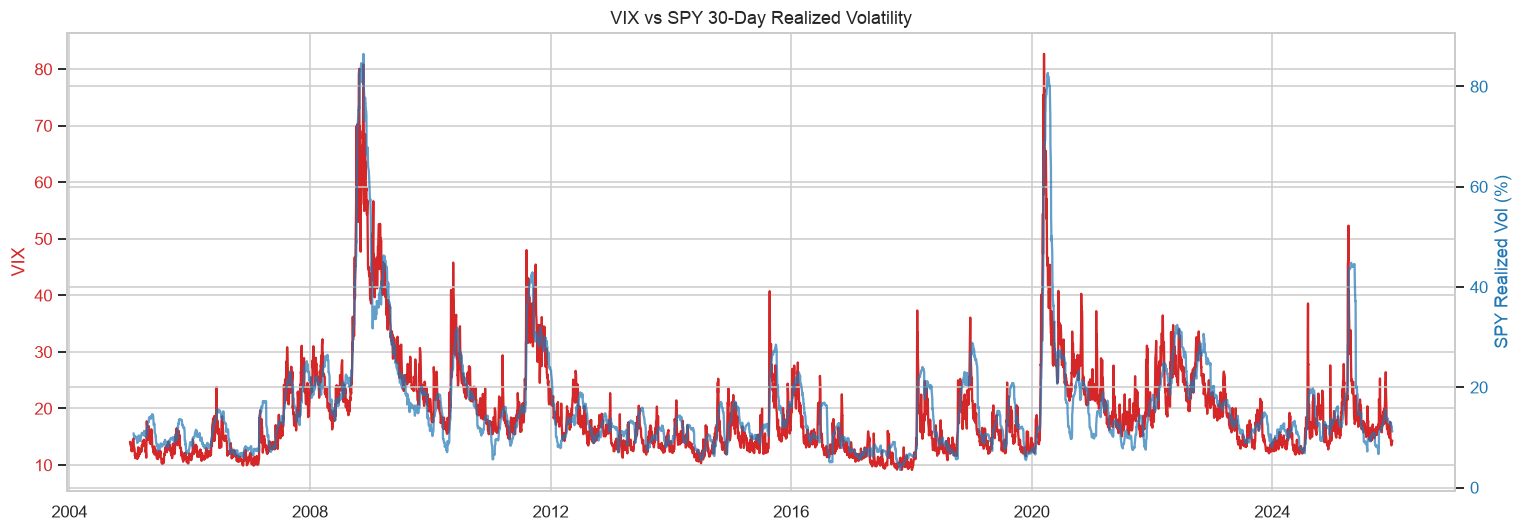

In [13]:
vix_aligned = vix_series.reindex(spy_rv30.index).ffill()

fig, ax1 = plt.subplots(figsize=(14, 5))
ax1.plot(vix_aligned.index, vix_aligned.values, color="#d62728", label="VIX")
ax1.set_ylabel("VIX", color="#d62728")
ax1.tick_params(axis="y", labelcolor="#d62728")

ax2 = ax1.twinx()
ax2.plot(spy_rv30.index, spy_rv30.values, color="#1f77b4", alpha=0.7,
          label="SPY 30d Realized Vol (annualized %)")
ax2.set_ylabel("SPY Realized Vol (%)", color="#1f77b4")
ax2.tick_params(axis="y", labelcolor="#1f77b4")

ax1.set_title("VIX vs SPY 30-Day Realized Volatility")
plt.tight_layout()
plt.savefig("../reports/figs_01_vix_vs_realized_vol.png", dpi=150, bbox_inches="tight")
plt.show()

In [14]:
# Contemporaneous correlation
contemp_corr = vix_aligned.corr(spy_rv30)
# VIX today vs realized vol over the NEXT 30 days (predictive test)
future_rv30 = spy_rv30.shift(-30)
predictive_corr = vix_aligned.corr(future_rv30)

print(f"Contemporaneous correlation (VIX vs same-window realized vol): {contemp_corr:.3f}")
print(f"Predictive correlation (VIX vs NEXT 30-day realized vol):      {predictive_corr:.3f}")

Contemporaneous correlation (VIX vs same-window realized vol): 0.869
Predictive correlation (VIX vs NEXT 30-day realized vol):      0.666


**Interpretation:**  
VIX shows a strong contemporaneous correlation with realized volatility (0.869), which is expected since both measures reflect the same underlying market conditions at a given point in time. However, VIX's predictive power drops meaningfully when tested against future realized volatility (0.666 correlation with the next 30 days). This confirms that VIX has genuine forward-looking value (a correlation of 0.666 is far from negligible) but is an imperfect predictor: it captures general volatility regimes reasonably well, while sudden unanticipated shocks can still push realized volatility above or below what VIX had priced in. This distinction supports including VIX as a regime feature in Capstone Step 2, while acknowledging it should not be treated as a precise volatility forecast on its own.

## Summary
- Data covers 50 S&P 500 tickers, 2005-2025, ~259K rows, with VIX and 10Y Treasury as
  supplementary market/regime features.
- Adjusted Close and log returns are used throughout, for the reasons documented in
  Section 2.
- No unexpected missing data; the only NaNs are the expected first-day-per-ticker log
  returns, and a subset of tickers have shorter histories due to later listings.
- Volatility clustering and non-stationarity are visually confirmed (Section 5), which
  motivates the walk-forward validation approach used later in the LSTM step, rather than
  a single static train/test split.
- Correlation and VIX analyses (Sections 6-7) support including VIX and rolling
  correlation-derived features as regime indicators in Capstone Step 2 (Preprocessing).

**Next step:** `02_preprocessing.ipynb`: technical indicators (RSI, MACD, Bollinger,
ATR, OBV), temporal train/val/test split, and feature normalization.